## 1. Import Learners
Test that all learner modules can be imported successfully.

In [41]:
import numpy as np
from dml.learners.lasso import LassoLearner
from dml.learners.elastic_net import ElasticNetLearner
from dml.learners.random_forest import RandomForestLearner
from dml.learners.neural_net import NeuralNetLearner
from dml.learners.causal_forest import CausalForestLearner
from dml.models.plr import PLR
from dml.models.irm import IRM
from dml.utils.cross_fitting import cross_fit
from dml.utils.orthogonality import verify_plr_orthogonality, verify_irm_orthogonality
from dml.utils.efficiency_bound import plr_efficiency_bound, compare_learner_efficiency

print("All imports successful!")

All imports successful!


## 2. Basic Fit & Predict Test
Verify that all three learners can fit on synthetic data and return predictions of the correct shape.

In [42]:
np.random.seed(42)
n, p = 100, 5
X = np.random.randn(n, p)
y = X @ np.ones(p) + np.random.randn(n)

learners = {
    "Lasso": LassoLearner(),
    "ElasticNet": ElasticNetLearner(),
    "RandomForest": RandomForestLearner(),
    "NeuralNet": NeuralNetLearner(),
    "CausalForest": CausalForestLearner(),
}

for name, learner in learners.items():
    learner.fit(X, y)
    y_pred = learner.predict(X)
    print(f"{name}: output shape = {y_pred.shape}, first 3 predictions = {y_pred[:3].round(2)}")

Lasso: output shape = (100,), first 3 predictions = [ 2.12  1.96 -4.35]
ElasticNet: output shape = (100,), first 3 predictions = [ 2.12  1.97 -4.36]
RandomForest: output shape = (100,), first 3 predictions = [ 2.32  2.96 -4.64]
NeuralNet: output shape = (100,), first 3 predictions = [ 2.68  2.38 -4.55]
CausalForest: output shape = (100,), first 3 predictions = [ 0.13  0.87 -1.05]


## 3. Cross-fitting Test
Verify that cross-fitting produces out-of-sample predictions for all observations.

In [43]:
learner = LassoLearner()
y_pred_cf = cross_fit(learner, X, y, n_splits=5, random_state=66)

print(f"Input shape: {y.shape}")
print(f"Output shape: {y_pred_cf.shape}")
print(f"Residuals (first 5): {(y - y_pred_cf)[:5].round(3)}")

Input shape: (100,)
Output shape: (100,)
Residuals (first 5): [ 0.991  2.292 -1.494  0.698 -0.425]


## 4. Aggregated DML + Honest Cross-fitting Test
Verify that cross_fit_aggregated and cross_fit_honest work correctly.

In [44]:
# NOTE: cross_fit_honest is part of Extension (Honest Cross-fitting)
# included here for completeness but not part of main results
from dml.utils.cross_fitting import cross_fit_aggregated, cross_fit_honest

np.random.seed(66)
n, p = 200, 10
X = np.random.randn(n, p)
y = X @ np.ones(p) + np.random.randn(n)

learner = LassoLearner()

y_pred_std = cross_fit(learner, X, y, random_state=66)
y_pred_agg = cross_fit_aggregated(learner, X, y, n_rep=10, random_state=66)
y_pred_hon = cross_fit_honest(LassoLearner(), LassoLearner(), X, y, random_state=66)

print(f"Standard:   shape={y_pred_std.shape}, MSE={np.mean((y-y_pred_std)**2):.4f}")
print(f"Aggregated: shape={y_pred_agg.shape}, MSE={np.mean((y-y_pred_agg)**2):.4f}")
print(f"Honest:     shape={y_pred_hon.shape}, MSE={np.mean((y-y_pred_hon)**2):.4f}")

Standard:   shape=(200,), MSE=1.4226
Aggregated: shape=(200,), MSE=1.4316
Honest:     shape=(200,), MSE=3.7882


## 5. PLR Verification
Verify that PLR correctly estimates theta on synthetic data where true theta_0 = 1.

In [45]:
# synthetic data, true theta_0 = 1
np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0
D = X @ np.random.randn(p) + np.random.randn(n)
Y = theta_0 * D + X @ np.random.randn(p) + np.random.randn(n)

# run PLR with Lasso
plr = PLR(learner=LassoLearner(), n_splits=5, random_state=66)
plr.fit(Y, D, X)
results = plr.predict()

print(f"True theta_0:    {theta_0}")
print(f"Estimated theta: {results['theta']:.4f}")
print(f"95% CI: ({results['ci_lower']:.4f}, {results['ci_upper']:.4f})")
print(f"CI contains true theta: {results['ci_lower'] < theta_0 < results['ci_upper']}")

True theta_0:    1.0
Estimated theta: 0.9545
95% CI: (0.8652, 1.0438)
CI contains true theta: True


## 6. IRM Verification
Verify that IRM correctly estimates ATE on synthetic binary treatment data.

In [46]:
# synthetic data, true theta_0 = 1.0, binary treatment
np.random.seed(66)
n = 500
X = np.random.randn(n, 5)
D = (np.random.randn(n) > 0).astype(float)
g0_true = np.sin(X[:, 0])
g1_true = np.sin(X[:, 0]) + 1.0
Y = D * 1.0 + g0_true + np.random.randn(n)
theta_0 = 1.0

# run IRM with Lasso
irm = IRM(learner=LassoLearner(), n_splits=5, random_state=66)
irm.fit(Y, D, X)
results = irm.predict()

print(f"True theta_0:    {theta_0}")
print(f"Estimated theta: {results['theta']:.4f}")
print(f"95% CI: ({results['ci_lower']:.4f}, {results['ci_upper']:.4f})")
print(f"CI contains true theta: {results['ci_lower'] < theta_0 < results['ci_upper']}")

True theta_0:    1.0
Estimated theta: 1.1493
95% CI: (0.9712, 1.3274)
CI contains true theta: True


## 7. Clean Import Test
Verify that the package-level imports work correctly.

In [47]:
from dml import (
    LassoLearner, ElasticNetLearner, RandomForestLearner,
    CausalForestLearner, NeuralNetLearner,
    PLR, IRM
)

print("Package-level imports successful!")

Package-level imports successful!


## 8. Neural Network Learner Test
Verify that NeuralNetLearner works as a drop-in replacement for other learners.

In [48]:
np.random.seed(66)
n, p = 200, 10
X = np.random.randn(n, p)
y = X @ np.ones(p) + np.random.randn(n)

nn_learner = NeuralNetLearner(hidden_sizes=[64, 32], random_state=66)
nn_learner.fit(X, y)
y_pred = nn_learner.predict(X)

print(f"NeuralNet: output shape = {y_pred.shape}")
print(f"First 3 predictions = {y_pred[:3].round(2)}")

# compare MSE with baseline
mse_nn = np.mean((y - y_pred) ** 2)
mse_baseline = np.mean((y - np.mean(y)) ** 2)
print(f"MSE (NN): {mse_nn:.4f}")
print(f"MSE (baseline): {mse_baseline:.4f}")
print(f"NN better than baseline: {mse_nn < mse_baseline}")

NeuralNet: output shape = (200,)
First 3 predictions = [-0.06  5.37 -1.65]
MSE (NN): 1.5636
MSE (baseline): 10.8453
NN better than baseline: True


## 9. JAX Orthogonality Verification
Verify that the Neyman orthogonality condition holds for PLR and IRM scores.
Expected: derivative ≈ 0 at true parameters.

In [49]:
np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0

# PLR data
D_plr = X @ np.random.randn(p) + np.random.randn(n)
Y_plr = theta_0 * D_plr + X @ np.random.randn(p) + np.random.randn(n)

# get nuisance estimates using Lasso
learner = LassoLearner()
l_hat = cross_fit(learner, X, Y_plr, random_state=66)
m_hat = cross_fit(learner, X, D_plr, random_state=66)

# verify PLR orthogonality
result_plr = verify_plr_orthogonality(Y_plr, D_plr, l_hat, m_hat, theta_0)
print("PLR Orthogonality:")
print(f"  Score at estimated nuisance: {result_plr['score_at_estimated_nuisance']:.6f}")
print(f"  Mean |deriv| wrt l(X):       {result_plr['mean_abs_deriv_wrt_l']:.6f}")
print(f"  Mean |deriv| wrt m(X):       {result_plr['mean_abs_deriv_wrt_m']:.6f}")
print(f"  Max |deriv| overall:         {result_plr['max_abs_derivative']:.6f}")
print(f"  Note: {result_plr['note']}")

PLR Orthogonality:
  Score at estimated nuisance: -0.050701
  Mean |deriv| wrt l(X):       0.003764
  Mean |deriv| wrt m(X):       0.006114
  Max |deriv| overall:         0.015639
  Note: Small directional derivatives provide numerical support for orthogonality.


In [55]:
from sklearn.model_selection import KFold

# synthetic binary treatment data
np.random.seed(66)
n = 500
X = np.random.randn(n, 5)
D = (np.random.randn(n) > 0).astype(float)
g0_true = np.sin(X[:, 0])
g1_true = np.sin(X[:, 0]) + 1.0
Y = D * 1.0 + g0_true + np.random.randn(n)
theta_0 = 1.0

# cross-fit nuisance estimates
kf = KFold(n_splits=5, shuffle=True, random_state=66)
learner = LassoLearner()

m_hat = np.zeros(n)
g0_hat = np.zeros(n)
g1_hat = np.zeros(n)

for train_idx, test_idx in kf.split(X):
    learner.fit(X[train_idx], D[train_idx])
    m_hat[test_idx] = learner.predict(X[test_idx])
m_hat = np.clip(m_hat, 0.01, 0.99)

for train_idx, test_idx in kf.split(X):
    idx0 = train_idx[D[train_idx] == 0]
    learner.fit(X[idx0], Y[idx0])
    g0_hat[test_idx] = learner.predict(X[test_idx])

for train_idx, test_idx in kf.split(X):
    idx1 = train_idx[D[train_idx] == 1]
    learner.fit(X[idx1], Y[idx1])
    g1_hat[test_idx] = learner.predict(X[test_idx])

# verify IRM orthogonality
result = verify_irm_orthogonality(g0_hat, g1_hat, m_hat, Y, D, theta_0)
print("IRM Orthogonality:")
print(f"  Score at estimated nuisance: {result['score_at_estimated_nuisance']:.6f}")
print(f"  Mean |deriv| wrt g0:         {result['mean_abs_deriv_wrt_g0']:.6f}")
print(f"  Mean |deriv| wrt g1:         {result['mean_abs_deriv_wrt_g1']:.6f}")
print(f"  Mean |deriv| wrt m(X):       {result['mean_abs_deriv_wrt_m']:.6f}")
print(f"  Max |deriv| overall:         {result['max_abs_derivative']:.6f}")
print(f"  Note: {result['note']}")

IRM Orthogonality:
  Score at estimated nuisance: 0.149321
  Mean |deriv| wrt g0:         0.000267
  Mean |deriv| wrt g1:         0.000339
  Mean |deriv| wrt m(X):       0.001901
  Max |deriv| overall:         0.004452
  Note: Small directional derivatives provide numerical support for orthogonality.


## 10. Semiparametric Efficiency Bound
Compare each learner's variance against the theoretical efficiency bound.

In [64]:
np.random.seed(66)
n, p = 500, 20
X = np.random.randn(n, p)
theta_0 = 1.0
D = X @ np.random.randn(p) + np.random.randn(n)
Y = theta_0 * D + X @ np.random.randn(p) + np.random.randn(n)

learner_classes = {
    "Lasso": LassoLearner,
    "RandomForest": RandomForestLearner,
    "NeuralNet": NeuralNetLearner,
}

print(f"{'Learner':<15} {'V*':>10} {'Actual Var':>12} {'Ratio':>8} {'Efficient':>10}")
print("-" * 60)

for name, learner_class in learner_classes.items():
    plr = PLR(learner=learner_class(), n_splits=5, random_state=66)
    plr.fit(Y, D, X)
    results = plr.predict()

    Y_hat = cross_fit(learner_class(), X, Y, random_state=66)
    D_hat = cross_fit(learner_class(), X, D, random_state=66)
    Y_tilde = Y - Y_hat
    D_tilde = D - D_hat

    comparison = compare_learner_efficiency(Y_tilde, D_tilde,
                                            results['theta'],
                                            results['var'])
    print(f"{name:<15} {comparison['efficiency_bound']:>10.6f} "
          f"{comparison['actual_variance']:>12.6f} "
          f"{comparison['efficiency_ratio']:>8.3f} "
          f"{str(comparison['is_efficient']):>10}")

Learner                 V*   Actual Var    Ratio  Efficient
------------------------------------------------------------
Lasso             0.001840     0.002074    1.127       True
RandomForest      0.000088     0.000896   10.243      False
NeuralNet         0.001867     0.002510    1.344       True


In [68]:
# JAX efficiency bound — Lasso
plr = PLR(learner=LassoLearner(), n_splits=5, random_state=66)
plr.fit(Y, D, X)
results = plr.predict()

Y_hat = cross_fit(LassoLearner(), X, Y, random_state=66)
D_hat = cross_fit(LassoLearner(), X, D, random_state=66)
Y_tilde = Y - Y_hat
D_tilde = D - D_hat

# JAX version
jax_result = plr_efficiency_bound_jax(Y_tilde, D_tilde, results['theta'])
print("JAX version:")
print(f"  V* = {jax_result['efficiency_bound']:.6f}")
print(f"  J (JAX grad) = {jax_result['J_jax']:.6f}")
print(f"  Actual var   = {results['var']:.6f}")
print(f"  Ratio        = {results['var'] / jax_result['efficiency_bound']:.3f}")

JAX version:
  V* = 0.001840
  J (JAX grad) = 1.113876
  Actual var   = 0.002074
  Ratio        = 1.127


## 11. DoubleML Benchmark
Compare our PLR implementation against the official DoubleML package.
Target: point estimate difference < 0.01, CI bounds roughly match.

In [76]:
from doubleml.plm.datasets import make_plr_CCDDHNR2018
from sklearn.linear_model import Lasso
import doubleml as dml
import pandas as pd

# use standard CCDDHNR2018 DGP — same as Exp 1 and Exp 2
np.random.seed(66)
X_bm, Y_bm, D_bm = make_plr_CCDDHNR2018(
    alpha=0.5, n_obs=500, dim_x=20, return_type='array'
)
theta_0_bm = 0.5  # alpha = theta_0

# our PLR implementation
our_plr = PLR(learner=LassoLearner(), n_splits=5, random_state=66)
our_plr.fit(Y_bm, D_bm, X_bm)
our_results = our_plr.predict()

# official DoubleML PLR
col_names = [f"X{i}" for i in range(20)]
df_bm = pd.DataFrame(X_bm, columns=col_names)
df_bm['Y'] = Y_bm
df_bm['D'] = D_bm

dml_data = dml.DoubleMLData(df_bm, y_col='Y', d_cols='D', x_cols=col_names)
dml_plr = dml.DoubleMLPLR(
    dml_data,
    ml_l=Lasso(alpha=0.1),
    ml_m=Lasso(alpha=0.1),
    n_folds=5,
    score='partialling out'
)
dml_plr.fit()

official_theta = dml_plr.coef[0]
official_ci = dml_plr.confint().values[0]

print(f"{'':20} {'Theta':>10} {'CI Lower':>10} {'CI Upper':>10}")
print("-" * 55)
print(f"{'Our PLR':20} {our_results['theta']:>10.4f} {our_results['ci_lower']:>10.4f} {our_results['ci_upper']:>10.4f}")
print(f"{'Official DoubleML':20} {official_theta:>10.4f} {official_ci[0]:>10.4f} {official_ci[1]:>10.4f}")
print(f"\nDifference: {abs(our_results['theta'] - official_theta):.4f}")
print(f"Target < 0.01: {abs(our_results['theta'] - official_theta) < 0.01}")

                          Theta   CI Lower   CI Upper
-------------------------------------------------------
Our PLR                  0.4551     0.3658     0.5444
Official DoubleML        0.4489     0.3601     0.5378

Difference: 0.0061
Target < 0.01: True


In [77]:
from sklearn.linear_model import Lasso, LogisticRegression

# IRM Benchmark
np.random.seed(66)
n = 500
X_irm = np.random.randn(n, 5)
D_irm = (np.random.randn(n) > 0).astype(float)
g0_true = np.sin(X_irm[:, 0])
Y_irm = D_irm * 1.0 + g0_true + np.random.randn(n)
theta_0_irm = 1.0

# our IRM implementation
our_irm = IRM(learner=LassoLearner(), n_splits=5, random_state=66)
our_irm.fit(Y_irm, D_irm, X_irm)
our_irm_results = our_irm.predict()

# official DoubleML IRM
col_names_irm = [f"X{i}" for i in range(5)]
df_irm = pd.DataFrame(X_irm, columns=col_names_irm)
df_irm['Y'] = Y_irm
df_irm['D'] = D_irm

dml_data_irm = dml.DoubleMLData(df_irm, y_col='Y', d_cols='D', x_cols=col_names_irm)
dml_irm = dml.DoubleMLIRM(
    dml_data_irm,
    ml_g=Lasso(alpha=0.1),
    ml_m=LogisticRegression(),  # classifier for binary D
    n_folds=5,
    score='ATE'
)
dml_irm.fit()

official_irm_theta = dml_irm.coef[0]
official_irm_ci = dml_irm.confint().values[0]

print(f"{'':20} {'Theta':>10} {'CI Lower':>10} {'CI Upper':>10}")
print("-" * 55)
print(f"{'Our IRM':20} {our_irm_results['theta']:>10.4f} {our_irm_results['ci_lower']:>10.4f} {our_irm_results['ci_upper']:>10.4f}")
print(f"{'Official DoubleML':20} {official_irm_theta:>10.4f} {official_irm_ci[0]:>10.4f} {official_irm_ci[1]:>10.4f}")
print(f"\nDifference: {abs(our_irm_results['theta'] - official_irm_theta):.4f}")

                          Theta   CI Lower   CI Upper
-------------------------------------------------------
Our IRM                  1.1493     0.9712     1.3274
Official DoubleML        1.1470     0.9638     1.3302

Difference: 0.0023


## 12. Experiment 1 — Estimator Comparison by Learner
For each learner: non-orthogonal ML vs DML no split vs DML cross-fitting.
Starting with Lasso and ElasticNet today.

[Lasso] Replication 0/500...
[Lasso] Replication 100/500...
[Lasso] Replication 200/500...
[Lasso] Replication 300/500...
[Lasso] Replication 400/500...
[Lasso] Valid reps: 500/500


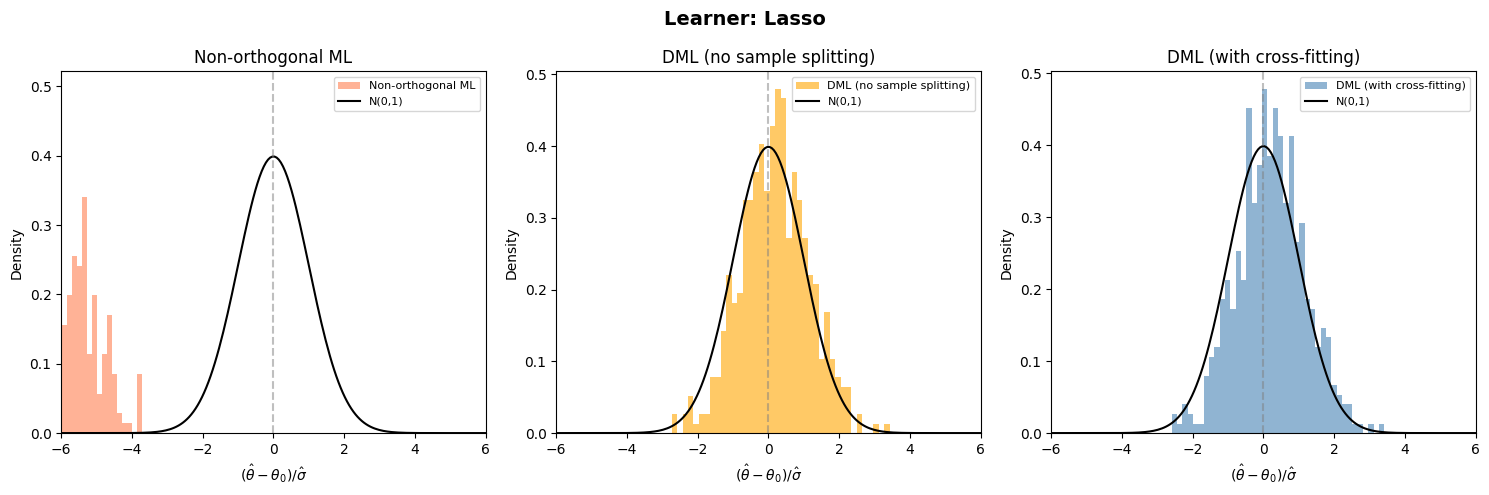

[RandomForest] Replication 0/500...
[RandomForest] Replication 100/500...
[RandomForest] Replication 200/500...
[RandomForest] Replication 300/500...
[RandomForest] Replication 400/500...
[RandomForest] Valid reps: 500/500


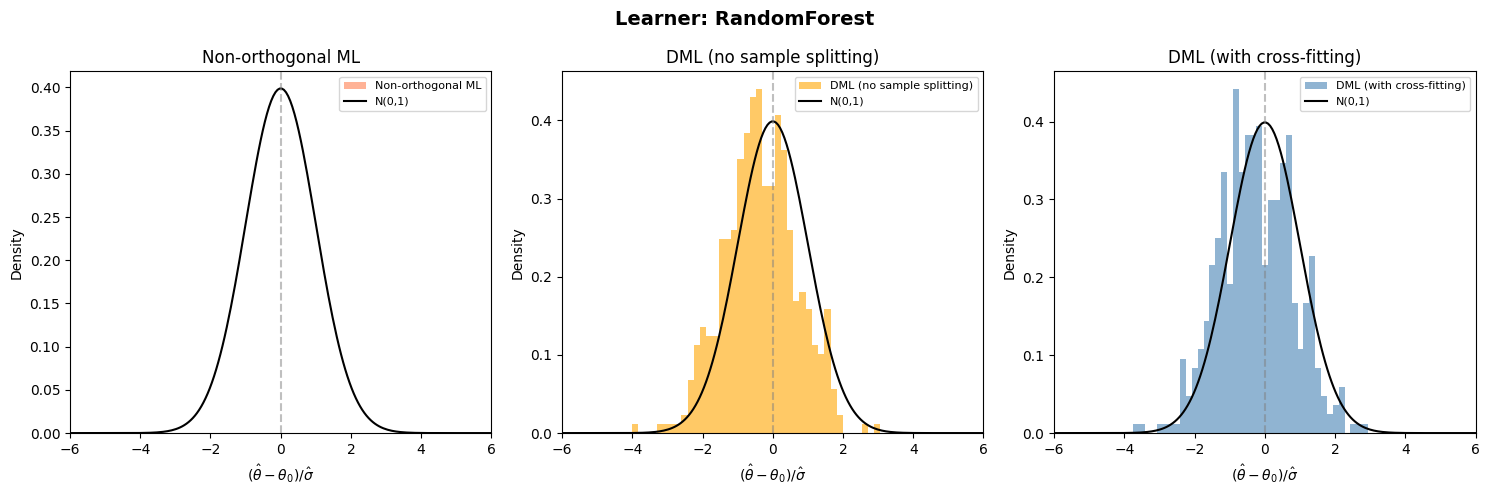

[NeuralNet] Replication 0/500...
[NeuralNet] Replication 100/500...
[NeuralNet] Replication 200/500...
[NeuralNet] Replication 300/500...
[NeuralNet] Replication 400/500...
[NeuralNet] Valid reps: 500/500


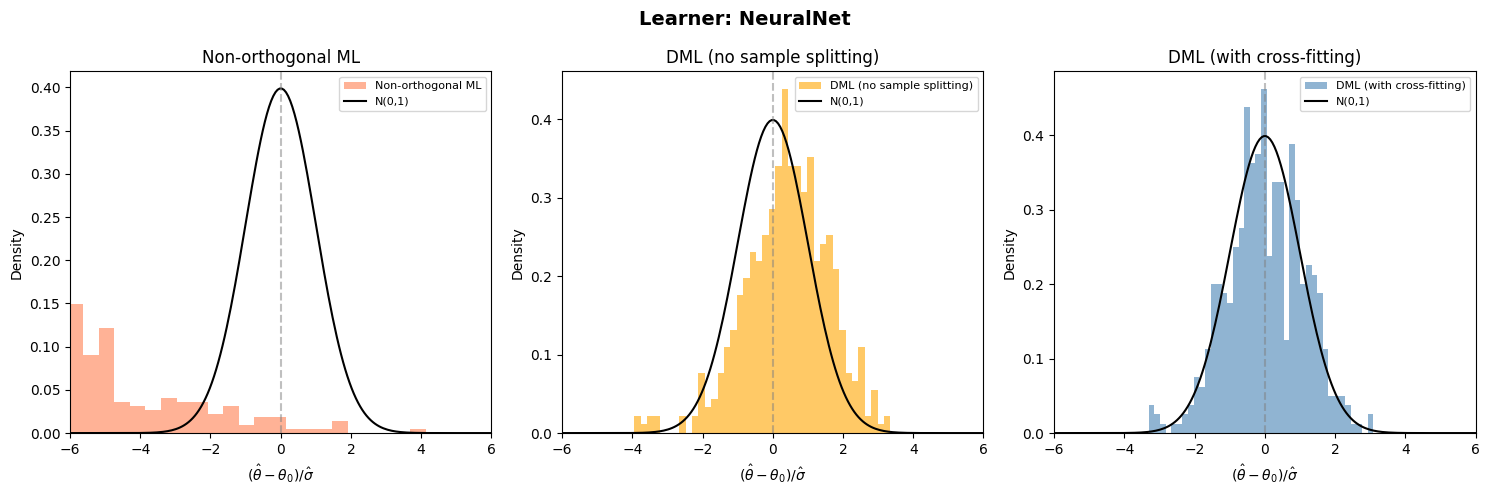

In [80]:
from experiments.exp1_estimator_comparison import run_experiment_1, plot_experiment_1

# Lasso
results_lasso = run_experiment_1('Lasso', LassoLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_lasso, 'Lasso',
                  save_path='../results/exp1_lasso.png')

# RandomForest
results_rf = run_experiment_1('RandomForest', RandomForestLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_rf, 'RandomForest',
                  save_path='../results/exp1_rf.png')

# NeuralNet
results_nn = run_experiment_1('NeuralNet', NeuralNetLearner, n_obs=500, n_reps=500)
plot_experiment_1(results_nn, 'NeuralNet',
                  save_path='../results/exp1_nn.png')

## 13. Experiment 2 — Learner Comparison
Five learners × n ∈ {200, 500, 1000, 2000}, 500 reps each.
Metrics: bias, RMSE, CI coverage rate.

[Lasso] n=200...
  bias=0.0051, rmse=0.0716, coverage=0.940
[Lasso] n=500...
  bias=0.0092, rmse=0.0442, coverage=0.946
[Lasso] n=1000...
  bias=0.0072, rmse=0.0323, coverage=0.928
[Lasso] n=2000...
  bias=0.0057, rmse=0.0244, coverage=0.922
[RandomForest] n=200...
  bias=-0.0103, rmse=0.0762, coverage=0.924
[RandomForest] n=500...
  bias=-0.0107, rmse=0.0481, coverage=0.946
[RandomForest] n=1000...
  bias=-0.0107, rmse=0.0347, coverage=0.926
[RandomForest] n=2000...
  bias=-0.0126, rmse=0.0287, coverage=0.870
[NeuralNet] n=200...
  bias=-0.0001, rmse=0.0770, coverage=0.898
[NeuralNet] n=500...
  bias=0.0003, rmse=0.0478, coverage=0.934
[NeuralNet] n=1000...
  bias=-0.0012, rmse=0.0329, coverage=0.940
[NeuralNet] n=2000...
  bias=-0.0020, rmse=0.0251, coverage=0.924
         learner  n_obs      bias      rmse  coverage  n_valid
0          Lasso    200  0.005107  0.071571     0.940      500
1          Lasso    500  0.009222  0.044207     0.946      500
2          Lasso   1000  0.007231 

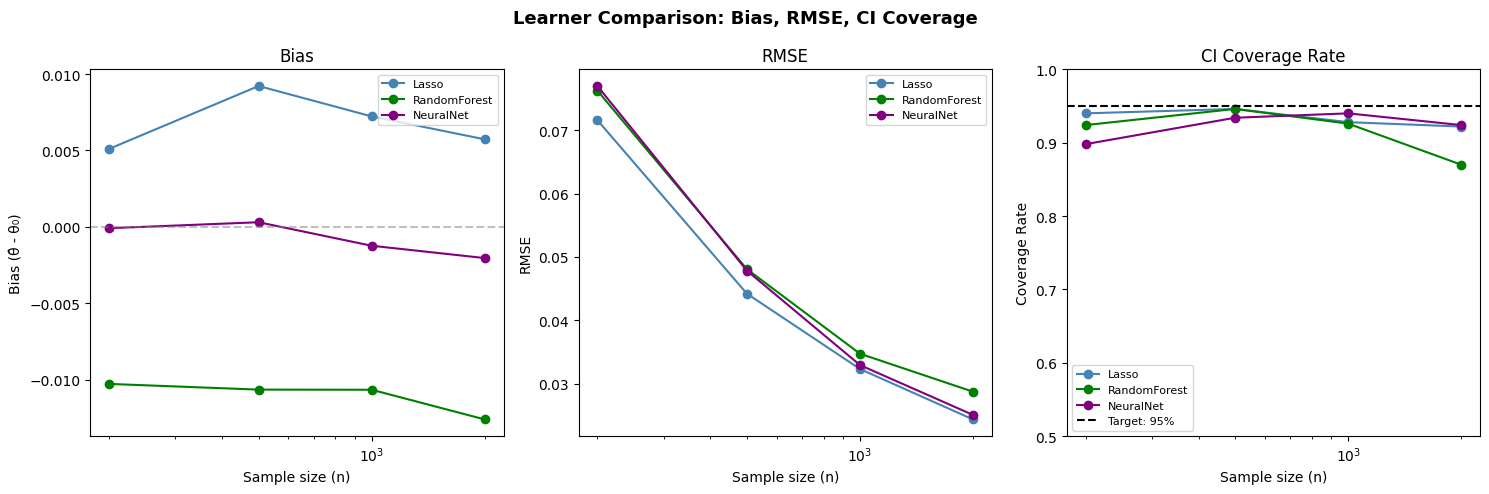

In [1]:
# Exp 2: Main learners (Lasso, RF, NN)
from experiments.exp2_learner_comparison import run_experiment_2, plot_experiment_2

df_exp2 = run_experiment_2(n_reps=500)
print(df_exp2)
plot_experiment_2(df_exp2,
                  save_path='../results/exp2_learner_comparison.png')

## 14. Experiment 3 — Convergence Rate Analysis
Verify that each learner's nuisance estimation satisfies the o(n^{-1/4}) rate condition from Chernozhukov et al. (2018).
Two sub-experiments: (a) nuisance RMSE vs n, (b) θ̂ RMSE vs n.

[Lasso] n=200...
[Lasso] n=500...
[Lasso] n=1000...
[Lasso] n=2000...
[Lasso] n=5000...
[RandomForest] n=200...
[RandomForest] n=500...
[RandomForest] n=1000...
[RandomForest] n=2000...
[RandomForest] n=5000...
[NeuralNet] n=200...
[NeuralNet] n=500...
[NeuralNet] n=1000...
[NeuralNet] n=2000...
[NeuralNet] n=5000...


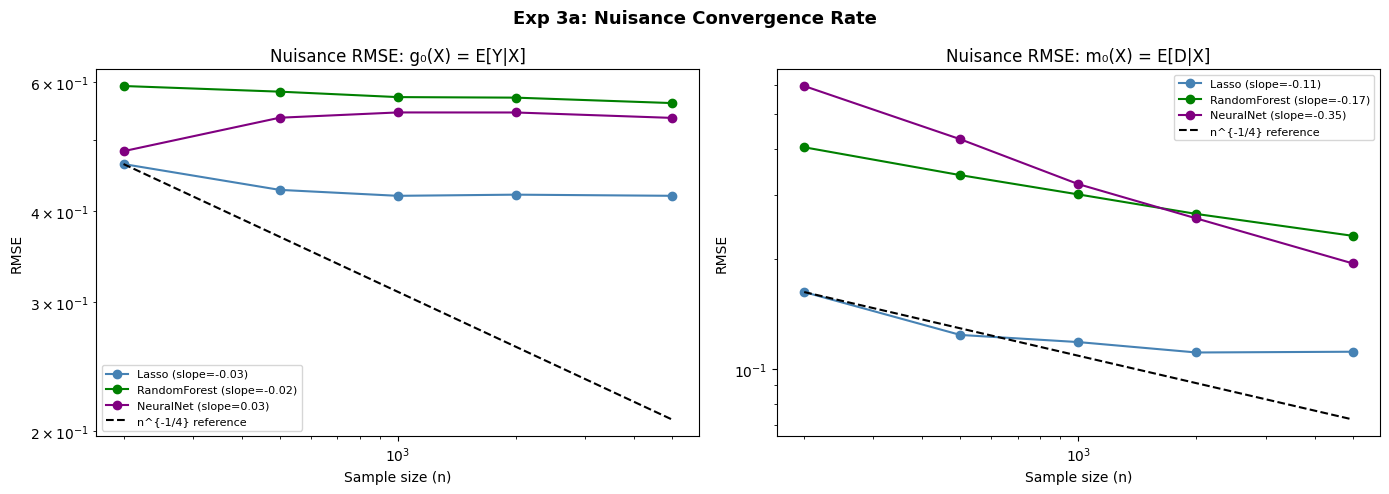

[Lasso] n=200...
[Lasso] n=500...
[Lasso] n=1000...
[Lasso] n=2000...
[Lasso] n=5000...
[RandomForest] n=200...
[RandomForest] n=500...
[RandomForest] n=1000...
[RandomForest] n=2000...
[RandomForest] n=5000...
[NeuralNet] n=200...
[NeuralNet] n=500...
[NeuralNet] n=1000...
[NeuralNet] n=2000...
[NeuralNet] n=5000...


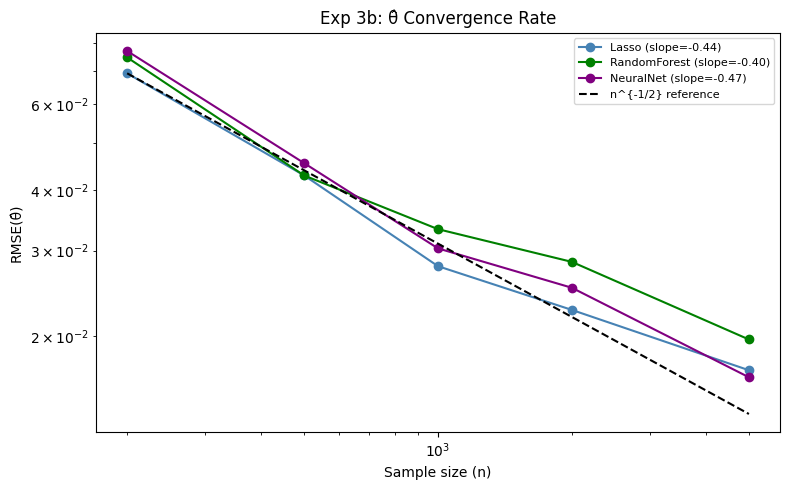

In [2]:
from experiments.exp3_convergence_rate import run_exp3a, run_exp3b, plot_exp3a, plot_exp3b

# Exp 3a: nuisance convergence
df_3a = run_exp3a(n_reps=100)
plot_exp3a(df_3a, save_path='../results/exp3a_nuisance_convergence.png')

# Exp 3b: theta convergence
df_3b = run_exp3b(n_reps=100)
plot_exp3b(df_3b, save_path='../results/exp3b_theta_convergence.png')

## 14. Experiment 4 — Tuned Learner Comparison
Compare baseline (default hyperparameters) vs tuned learners across sample sizes.
Inspired by Bach et al. (2024). Tuning: LassoCV, GridSearchCV (RF), Farrell architecture (NN).

In [1]:
from experiments.exp4_tuned_learner_comparison import (
    run_experiment_4, plot_experiment_4, LEARNERS_BASELINE
)
from experiments.exp2_learner_comparison import run_experiment_2

# 先用 n_reps=10 快速测试
df_tuned_test = run_experiment_4(n_reps=10)
print(df_tuned_test)

[Lasso_tuned] n=200...
  bias=0.0263, rmse=0.0809, coverage=0.900
[Lasso_tuned] n=500...
  bias=0.0018, rmse=0.0399, coverage=1.000
[Lasso_tuned] n=1000...
  bias=0.0103, rmse=0.0302, coverage=0.900
[Lasso_tuned] n=2000...
  bias=0.0007, rmse=0.0230, coverage=1.000
[RandomForest_tuned] n=200...
  bias=0.0325, rmse=0.0761, coverage=1.000
[RandomForest_tuned] n=500...
  bias=-0.0011, rmse=0.0482, coverage=1.000
[RandomForest_tuned] n=1000...
  bias=0.0089, rmse=0.0325, coverage=0.900
[RandomForest_tuned] n=2000...
  bias=0.0008, rmse=0.0233, coverage=0.900
[NeuralNet_tuned] n=200...
  bias=0.0440, rmse=0.0868, coverage=0.800
[NeuralNet_tuned] n=500...
  bias=0.0001, rmse=0.0646, coverage=0.800
[NeuralNet_tuned] n=1000...
  bias=0.0036, rmse=0.0310, coverage=1.000
[NeuralNet_tuned] n=2000...
  bias=-0.0021, rmse=0.0257, coverage=0.900
               learner  n_obs      bias      rmse  coverage  n_valid
0          Lasso_tuned    200  0.026317  0.080864       0.9       10
1          Lasso_t

## 15. Experiment 5 — DGP Robustness
Test whether learner rankings hold across different data-generating processes.
3 DGPs × 3 tuned learners: each DGP designed to favor one learner (Lasso, RF, NN).

In [2]:
# Exp 5 quick test — n_reps=5
from experiments.exp5_dgp_robustness import run_experiment_5, plot_experiment_5, plot_summary_table

df_exp5_test = run_experiment_5(n_reps=5)
print(df_exp5_test)

[Sparse_Linear] [Lasso] n=200...
  bias=0.0534, rmse=0.1140, coverage=0.800
[Sparse_Linear] [Lasso] n=500...
  bias=0.0143, rmse=0.0423, coverage=1.000
[Sparse_Linear] [Lasso] n=1000...
  bias=0.0154, rmse=0.0241, coverage=1.000
[Sparse_Linear] [RandomForest] n=200...
  bias=0.2941, rmse=0.3205, coverage=0.200
[Sparse_Linear] [RandomForest] n=500...
  bias=0.2063, rmse=0.2114, coverage=0.000
[Sparse_Linear] [RandomForest] n=1000...
  bias=0.1796, rmse=0.1819, coverage=0.000
[Sparse_Linear] [NeuralNet] n=200...
  bias=0.5454, rmse=0.5634, coverage=0.000
[Sparse_Linear] [NeuralNet] n=500...
  bias=0.2123, rmse=0.2263, coverage=0.200
[Sparse_Linear] [NeuralNet] n=1000...
  bias=0.0363, rmse=0.0513, coverage=0.800
[Piecewise] [Lasso] n=200...
  bias=0.2510, rmse=0.2556, coverage=0.000
[Piecewise] [Lasso] n=500...
  bias=0.1898, rmse=0.1939, coverage=0.000
[Piecewise] [Lasso] n=1000...
  bias=0.2078, rmse=0.2098, coverage=0.000
[Piecewise] [RandomForest] n=200...
  bias=0.0432, rmse=0.0916,